# VSE Simulation — standalone notebook

This notebook reproduces the **Voter Satisfaction Efficiency (VSE)** simulation methodology
originally developed in the [`vse-sim`](https://github.com/electionscience/vse-sim) project for
five voting systems: **Plurality, Approval, RCV/IRV, STAR, and Condorcet (Schulze)**.

**This notebook is fully standalone** — it has no dependency on the `vse-sim` repository or
package being installed or present. The "Vendored library" section below is a verbatim copy of
exactly the code these 5 methods need (electorate models, ballot logic, the VSE formula itself),
reproduced directly in this notebook's own cells. Only `numpy`, `scipy`, and `matplotlib` need to
be installed — this notebook can be shared, run on Colab, or embedded standalone anywhere.

It does **not** reimplement the methodology — every honest ballot, every strategic ballot, and
the VSE formula are the same code that produced the published numbers in this project's
[`docs/VSEbasic.md`](https://github.com/electionscience/vse-sim/blob/main/docs/VSEbasic.md) and
[`docs/irv-simulation.md`](https://github.com/electionscience/vse-sim/blob/main/docs/irv-simulation.md)
(see the note in Section 7 below about one known discrepancy between that table and the current
code).

**New in this version:** epistemic noise — voters cast ballots on a *perceived* utility that's a
noisy version of their true utility, modeling the idea that voters may be uncertain about their
own preferences or misinformed about candidates. See the "Epistemic noise" sections below.

**Not included (deferred to a future checkpoint):** participation friction / ballot fatigue
(forced ballot truncation), and top-2/top-3 hybrid methods (e.g. Approval Top 2, "Approval Top 3
→ Schulze"). Section 12 ("Next steps") describes where these would hook in.

**Also dropped:** Ranked Pairs (a second Condorcet completion method) — Schulze alone represents
Condorcet going forward.


## How this notebook is organized

1. **Vendored library** — self-contained copy of the electorate models, ballot logic, and VSE
   formula (sections below, mirroring the original project's module layout).
2. **Epistemic noise** — the one new mechanism added in this version.
3. **Parameters** — the knobs you'll actually want to change.
4. **Methods** — the 5 voting systems being compared.
5. **Simulation loop, Run, Results, Sanity check, Chart** — run the simulation and look at VSE.
6. **Epistemic noise demo** — VSE vs. voter information.
7. **Next steps** — what's deliberately not built yet, and where it would hook in.


## 1. Vendored library

The classes and functions below are copied, with one small and clearly-marked addition, from the
`vse_sim` Python package at [electionscience/vse-sim](https://github.com/electionscience/vse-sim)
(the repository this notebook was originally developed alongside), so this notebook has zero
dependency on that repository being present. Internal `from .xxx import yyy` lines between the
original package's own modules are simply omitted here — everything lives in this one notebook's
namespace instead, in the same dependency order the original modules load in.

**Included:** the shared `Method` base class and VSE formula (`core.py`), the electorate/voter
models needed for the "kitchen sink" hierarchical-cluster model used for every published VSE
number (`voter_models.py`, trimmed to what `KSModel` needs), the strategic-voting and media-noise
machinery (`strategies.py`), and the 5 requested voting methods (`methods/*.py`).

**Not included:** anything only needed by voting methods this notebook doesn't use (Ranked
Pairs, Majority Judgment, Borda, 3-2-1, IRNR, ...), the CSV/batch-run harness (`CsvBatch`), and a
few electorate models unrelated to the one used here (`PolyaModel`, `QModel`, `ReverseModel`,
`DeterministicModel`).

**One deliberate modification:** `Method.resultsTable`/`vseOn` gain an optional `scoring_voters`
parameter (defaulting to the original behavior when omitted) — see Section 2, "Epistemic noise",
for why.


### 1.1 Setup: shared imports

In [4]:
import random
import math
import time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt


### 1.2 Utility decorators (from `decorators.py`)

In [5]:
from functools import update_wrapper, wraps
from inspect import getfullargspec, isfunction
from itertools import starmap


def decorator(d):
    """Make function d a decorator: d wraps a function fn."""
    def _d(fn):
        return update_wrapper(d(fn), fn)
    return _d
decorator = decorator(decorator)(decorator)


@decorator
def autoassign(*names, **kwargs):
    """
    autoassign(function) -> method
    autoassign(*argnames) -> decorator
    autoassign(exclude=argnames) -> decorator.

    Lets a method assign (some of) its arguments as attributes of ``self``
    automatically -- used throughout below instead of writing out
    ``self.x = x`` for every constructor argument.
    """
    if kwargs:
        exclude, f = set(kwargs['exclude']), None
        def sieve(values):
            return filter(lambda nv: nv[0] not in exclude, values)
    elif len(names) == 1 and isfunction(names[0]):
        f = names[0]
        def sieve(values):
            return values
    else:
        names, f = set(names), None
        def sieve(values):
            return [nv for nv in values if nv[0] in names]
    def decorator(f):
        spec = getfullargspec(f)
        fargnames, fdefaults = spec.args, spec.defaults
        fargnames, fdefaults = fargnames[1:], fdefaults or ()
        defaults = list(sieve(zip(reversed(fargnames), reversed(fdefaults), strict=False)))
        @wraps(f)
        def decorated(self, *args, **kwargs):
            assigned = dict(sieve(zip(fargnames, args, strict=False)))
            assigned.update(sieve(kwargs.items()))
            for _ in starmap(assigned.setdefault, defaults):
                pass
            self.__dict__.update(assigned)
            return f(self, *args, **kwargs)
        return decorated
    return f and decorator(f) or decorator


_missing = object()

@decorator
class cached_property(object):
    """Converts a function into a lazy property: computed once, then cached
    on the instance's own __dict__."""

    def __init__(self, func, name=None, doc=None):
        self.__name__ = name or func.__name__
        self.__module__ = func.__module__
        self.__doc__ = doc or func.__doc__
        self.func = func

    def __get__(self, obj, type=None):
        if obj is None:
            return self
        value = obj.__dict__.get(self.__name__, _missing)
        if value is _missing:
            value = self.func(obj)
            obj.__dict__[self.__name__] = value
        return value


### 1.3 Core: `Method` base class & VSE formula (from `core.py`)

`Method` is the shared base every voting method below subclasses. `normalized_vse` is the exact
formula behind every VSE number this notebook produces:
`vse = (util - rand) / (best - rand)`, where `best`/`rand` come from the electorate's true social
utilities (mean utility per candidate across all voters).

Two additions here (both marked inline): `resultsTable`/`vseOn` accept an optional
`scoring_voters` electorate. When ballots are cast on a *perceived* (possibly noisy) electorate
but VSE should still be scored against *true* utilities, pass the true electorate as
`scoring_voters` — see Section 2 below. They also stash that same true electorate as
`self._scoring_voters`, which the Top-2 hybrid methods in Section 3 read directly (their
"noiseless runoff" option needs true-utility access from inside `results()`, which doesn't
otherwise receive the electorate at all — see Section 3 for why).


In [6]:
from dataclasses import dataclass, field

from numpy import isclose, mean


def isnum(x):
    """Test whether an object is an instance of a built-in numeric type."""
    return next((1 for T in (int, float, complex) if isinstance(x, T)), 0)


class VseOneRun:
    @autoassign
    def __init__(self, result, tallyItems, strat):
        pass


class VseMethodRun:
    @autoassign
    def __init__(self, method, choosers, results):
        pass


@dataclass
class ElectionContext:
    """Mutable metadata scoped to one method instance and election."""
    extra_events: dict = field(default_factory=dict)


def normalized_vse(utility, best, random_baseline):
    """Normalize utility to VSE.

    When every candidate has the same social utility there is no possible
    improvement over random selection, so every method receives neutral VSE.
    """
    denominator = best - random_baseline
    if isclose(denominator, 0):
        return 0.0
    return (utility - random_baseline) / denominator


class SideTally(defaultdict):
    """Tracks how many voters are being strategic, etc.

    DO NOT use plain +; for this class it is equivalent to +=, but less readable.
    """
    def __init__(self):
        super().__init__(int)
        self._keys_initialized = False

    def initKeys(self, chooser):
        if self._keys_initialized:
            return
        try:
            self.keyList = chooser.allTallyKeys()
        except AttributeError:
            try:
                self.keyList = list(chooser)
            except TypeError:
                pass
        self._keys_initialized = True

    def serialize(self):
        try:
            return [self[key] for key in self.keyList]
        except AttributeError:
            return []

    def fullSerialize(self):
        try:
            return ([self[key] for key in self.keyList] +
                    [self[key] for key in self.keys() if key not in self.keyList])
        except AttributeError:
            return [self[key] for key in self.keys()]

    def itemList(self):
        try:
            kl = self.keyList
            return ([(k, self[k]) for k in kl] +
                    [(k, self[k]) for k in self.keys() if k not in kl])
        except AttributeError:
            return list(self.items())


class Tallies(list):
    """Used (ONCE) as an enumerator: gives an inexhaustible flow of SideTally
    objects. After that, use as a list to see those objects."""
    def __iter__(self):
        if hasattr(self, "used"):
            return super().__iter__()
        self.used = True
        return self

    def __next__(self):
        tally = SideTally()
        self.append(tally)
        return tally


class Method:
    """Base class for election methods. Holds some of the duct tape."""

    def __init__(self):
        self.context = ElectionContext()

    @property
    def extraEvents(self):
        """Compatibility view of metadata for this method's current election."""
        return self.context.extra_events

    @extraEvents.setter
    def extraEvents(self, value):
        self.context.extra_events = value

    def __str__(self):
        return self.__class__.__name__

    def results(self, ballots, **kwargs):
        """Combines ballots into results. Override for comparative methods."""
        if type(ballots) is not list:
            ballots = list(ballots)
        return list(map(self.candScore, zip(*ballots, strict=False)))

    @staticmethod  # cls is provided explicitly, not through binding
    def honBallot(cls, utils):
        """Takes utilities and returns an honest ballot."""
        raise NotImplementedError(f"{cls} needs honBallot")

    @staticmethod
    def winner(results):
        """Find the winner once scores are already calculated. Override for
        ranked methods."""
        winScore = max(result for result in results if isnum(result))
        winners = [cand for (cand, score) in enumerate(results) if score == winScore]
        return random.choice(winners)

    def honBallotFor(self, voters):
        """This is where you'd do any setup necessary and create an honBallot
        function. The base version just returns honBallot."""
        return self.honBallot

    def dummyBallotFor(self, polls):
        return lambda cls, utilities, stratTally: utilities

    def resultsFor(self, voters, chooser, tally=None, **kwargs):
        """Create ballots and get results."""
        if tally is None:
            tally = SideTally()
        tally.initKeys(chooser)
        return dict(results=self.results([chooser(self.__class__, voter, tally)
                                  for voter in voters],
                              **kwargs),
                chooser=chooser.__name__,
                tally=tally)

    def multiResults(self, voters, chooserFuns=(), media=(lambda x, t: x),
                checkStrat=True):
        """Runs the honest election, then the strategic election (based on the
        honest results filtered through media), then one-sided-strategic,
        'smart' one-sided, and any caller-supplied chooserFuns."""
        honTally = SideTally()
        self.context = ElectionContext()
        hon = self.resultsFor(voters, self.honBallotFor(voters), honTally, isHonest=True)

        stratTally = SideTally()
        polls = media(hon["results"], stratTally)
        winner, _w, target, _t = self.stratTargetFor(sorted(enumerate(polls), key=lambda x: -x[1]))

        strat = self.resultsFor(voters, self.stratBallotFor(polls), stratTally)

        ossTally = SideTally()
        oss = self.resultsFor(voters, self.ballotChooserFor(OssChooser()), ossTally)
        ossWinner = oss["results"].index(max(oss["results"]))
        ossTally["worked"] += (1 if ossWinner == target else
                                    (0 if ossWinner == winner else -1))

        smart = dict(results=(hon["results"] if ossTally["worked"] == 1 else oss["results"]),
                chooser="smartOss",
                tally=SideTally())

        extraTallies = Tallies()
        results = ([strat, oss, smart] +
                [self.resultsFor(voters, self.ballotChooserFor(chooserFun), aTally)
                    for (chooserFun, aTally) in zip(chooserFuns, extraTallies, strict=False)]
                  )
        return ([(hon["results"], hon["chooser"], list(self.extraEvents.items()))] +
                [(r["results"], r["chooser"], r["tally"].itemList()) for r in results])

    def vseOn(self, voters, chooserFuns=(), scoring_voters=None, **args):
        """Finds honest and strategic VSE for this method on the given electorate.

        `scoring_voters` -- CHECKPOINT-2 ADDITION, not in the original: the
        electorate whose socUtils defines ground truth for VSE scoring.
        Defaults to `voters` (the original behavior) when not given -- pass a
        separate true electorate here when `voters` is a noisy *perceived*
        electorate (see make_perceived_electorate below), so ballots are cast
        on perception while VSE is still scored against ground truth.
        """
        truth_voters = voters if scoring_voters is None else scoring_voters  # <-- checkpoint 2
        self._scoring_voters = truth_voters  # <-- checkpoint 3: exposed for Top2Base's noiseless-runoff option.
        # Must be set BEFORE multiResults() runs -- results() (called from deep inside
        # multiResults, via resultsFor) reads self._scoring_voters for this same election;
        # setting it after multiResults() returns would leave results() reading the PREVIOUS
        # election's true electorate (or None, on the very first call).
        multiResults = self.multiResults(voters, chooserFuns, **args)
        utils = truth_voters.socUtils
        best = max(utils)
        rand = mean(utils)

        vses = VseMethodRun(
            self.__class__,
            chooserFuns,
            [
                VseOneRun(
                    [normalized_vse(utils[self.winner(result)], best, rand)],
                    tally,
                    chooser,
                )
                for result, chooser, tally in multiResults
            ],
        )
        vses.extraEvents = dict(self.extraEvents)
        return vses

    def resultsTable(self, eid, emodel, cands, voters, chooserFuns=(), scoring_voters=None, **args):
        """As vseOn, but returns one CSV-row-shaped dict per chooser.
        See vseOn above for what `scoring_voters` (checkpoint-2 addition) does.
        """
        truth_voters = voters if scoring_voters is None else scoring_voters  # <-- checkpoint 2
        self._scoring_voters = truth_voters  # <-- checkpoint 3: exposed for Top2Base's noiseless-runoff option.
        # Must be set BEFORE multiResults() runs -- see the identical note in vseOn above.
        multiResults = self.multiResults(voters, chooserFuns, **args)
        utils = truth_voters.socUtils
        best = max(utils)
        rand = mean(utils)
        rows = []
        nvot = len(voters)
        for (result, chooser, tallyItems) in multiResults:
            winner = self.winner(result)
            utility = utils[winner]
            row = {
                "eid": eid,
                "emodel": emodel,
                "ncand": cands,
                "nvot": nvot,
                "best": best,
                "rand": rand,
                "method": str(self),
                "chooser": chooser,
                "util": utility,
                "vse": normalized_vse(utility, best, rand),
            }
            for (i, (k, v)) in enumerate(tallyItems):
                row[f"tallyName{str(i)}"] = str(k)
                row[f"tallyVal{str(i)}"] = str(v)
            rows.append(row)
        return rows

    @staticmethod
    def ballotChooserFor(chooserFun):
        """Takes a chooserFun; returns a ballot chooser using that chooserFun."""
        def ballotChooser(cls, voter, tally):
            return getattr(voter, f"{cls.__name__}_{chooserFun(cls, voter, tally)}")

        ballotChooser.__name__ = chooserFun.getName()
        return ballotChooser

    def stratTarget2(self, places):
        ((frontId, frontResult), (targId, targResult)) = places[:2]
        return (frontId, frontResult, targId, targResult)

    def stratTarget3(self, places):
        ((frontId, frontResult), (targId, targResult)) = places[:3:2]
        return (frontId, frontResult, targId, targResult)

    stratTargetFor = stratTarget2

    def stratBallotFor(self, polls):
        """Returns a (function which takes utilities and returns a strategic
        ballot) for the given 'polling' info."""
        places = sorted(enumerate(polls), key=lambda x: -x[1])  # high to low
        (frontId, frontResult, targId, targResult) = self.stratTargetFor(places)
        n = len(polls)
        @rememberBallots
        def stratBallot(cls, voter):
            stratGap = voter[targId] - voter[frontId]
            ballot = [0] * len(voter)
            isStrat = stratGap > 0
            extras = cls.fillStratBallot(voter, polls, places, n, stratGap, ballot,
                                frontId, frontResult, targId, targResult)
            result = dict(strat=ballot, isStrat=isStrat, stratGap=stratGap)
            if extras:
                result.update(extras)
            return result
        return stratBallot


@decorator
def rememberBallot(fun):
    """Decorator for a function xxxBallot(cls, voter) which memoizes the vote
    onto the voter in an attribute named <methName>_xxx."""
    def getAndRemember(cls, voter, tally=None):
        ballot = fun(cls, voter)
        setattr(voter, f"{cls.__name__}_{fun.__name__[:-6]}", ballot)
        return ballot

    getAndRemember.__name__ = fun.__name__
    getAndRemember.allTallyKeys = lambda: []
    return getAndRemember


@decorator
def rememberBallots(fun):
    """As rememberBallot, but fun returns a dict of {ballotType: ballot}."""
    def getAndRemember(cls, voter, tally=None):
        ballots = fun(cls, voter)
        for bType, ballot in ballots.items():
            setattr(voter, f"{cls.__name__}_{bType}", ballot)
        return ballots[fun.__name__[:-6]]  # leave off the "...Ballot"

    getAndRemember.__name__ = fun.__name__
    getAndRemember.allTallyKeys = lambda: []
    return getAndRemember


class CandidateWithCount:
    def __init__(self, c=[], v=0):
        self.candidate = c
        self.votes = v


### 1.4 Voter models (from `voter_models.py`, trimmed to what `KSModel` needs)

`KSModel` ("kitchen sink") is the hierarchical-cluster electorate model used to generate every
published VSE number in the original project: issue dimensions are grouped into nested "issue
clusters," voters are assigned to per-cluster "identity clusters" via a Chinese-restaurant
process, and each identity cluster has its own mean position and caring level. `RandomModel` is
also included below (needed as `KSModel`'s own base electorate) — it's the simpler "Impartial
Culture" model (independent random utilities) if you want to compare against it.


In [10]:
from numpy import mean
from numpy.lib.scimath import sqrt
from scipy.stats import beta


class Voter(tuple):
    """A tuple of candidate utilities."""

    def __new__(cls, utilities=()):
        return super().__new__(
            cls, (utility.item() if hasattr(utility, "item") else utility for utility in utilities)
        )

    @classmethod
    def rand(cls, ncand):
        """Create a random voter with an independent standard normal utility
        for each candidate."""
        return cls(random.gauss(0, 1) for _ in range(ncand))

    def hybridWith(self, v2, w2):
        """Create a weighted average of two voters. The weight of self is
        always 1; w2 is v2's weight relative to that. If both are standard
        normal to start with, the result will be standard normal too."""
        assert len(self) == len(v2)
        return self.copyWithUtils((self[i] / sqrt(1 + w2 ** 2)) +
                                    (w2 * v2[i] / sqrt(1 + w2 ** 2))
                                 for i in range(len(self)))

    def copyWithUtils(self, utils):
        """Create a new voter with attrs as self and given utils."""
        return self.__class__(utils)

    def mutantChild(self, muteWeight):
        """Returns a copy hybridized with a random voter of weight muteWeight."""
        return self.hybridWith(self.__class__.rand(len(self)), muteWeight)


class PersonalityVoter(Voter):

    cluster_count = 0

    def __init__(self, *args, **kw):
        super().__init__()
        self.cluster = self.__class__.cluster_count
        self.__class__.cluster_count += 1
        self.personality = random.gauss(0, 1)

    @classmethod
    def resetClusters(cls):
        cls.cluster_count = 0

    def copyWithUtils(self, utils):
        voter = super().copyWithUtils(utils)
        voter.copyAttrsFrom(self)
        return voter

    def copyAttrsFrom(self, model):
        self.personality = model.personality
        self.cluster = model.cluster


class Electorate(list):
    """A list of voters. Each voter is a list of candidate utilities."""
    @cached_property
    def socUtils(self):
        """Mean utility across the electorate for each candidate: the
        candidates' social utilities."""
        return [value.item() for value in map(mean, zip(*self, strict=False))]


class RandomModel:
    """Electorate factory implementing 'Impartial Culture': every voter gets
    an independent random utility for each candidate."""

    def __str__(self):
        return self.__class__.__name__

    def __call__(self, nvot, ncand, vType=PersonalityVoter):
        return Electorate(vType.rand(ncand) for _ in range(nvot))


class DimVoter(PersonalityVoter):
    """A voter in an n-dimensional ideology model."""

    @classmethod
    def fromDims(cls, v, e, caring=None):
        if caring is None:
            caring = [1] * len(v)
            totCaring = e.totWeight
        else:
            totCaring = sum((c * w) ** 2 for c, w in zip(caring, e.dimWeights, strict=False))
        me = cls(-sqrt(
            sum(((vd - cd) * w * cares) ** 2
                for (vd, cd, w, cares) in zip(v, c, e.dimWeights, caring, strict=False)) /
                            totCaring)
          for c in e.cands)
        me.copyAttrsFrom(v)
        me.dims = v
        me.elec = e
        return me


class DimElectorate(Electorate):

    def asDims(self, v, *args):
        return v

    def fromDims(self, dimvoters, vType):
        for v in dimvoters:
            self.append(vType.fromDims(v, self))

    def calcTotWeight(self):
        self.totWeight = sum(w ** 2 for w in self.dimWeights)


class DimModel(RandomModel):
    """N-dimensional ideology model: voters and candidates each get a
    position in n-dimensional space; utility falls off with distance."""

    builtElectorate = DimElectorate

    @autoassign
    def __init__(self, ndims=3, dimWeights=None, baseElectorate=RandomModel()):
        if self.dimWeights is None:
            self.dimWeights = [2 ** (-n) for n in range(ndims)]
        assert len(self.dimWeights) == self.ndims

    def __call__(self, nvot, ncand, vType=DimVoter):
        elec = self.builtElectorate()
        elec.dimWeights = self.dimWeights
        return self.makeElectorate(elec, nvot, ncand, vType)

    def makeElectorate(self, elec, nvot, ncand, vType):
        elec.calcTotWeight()
        votersncands = self.baseElectorate(nvot + ncand, len(elec.dimWeights), vType)
        elec.base = [elec.asDims(v, i) for i, v in enumerate(votersncands[:nvot])]
        elec.cands = [elec.asDims(v, nvot + i) for i, v in enumerate(votersncands[nvot:])]
        elec.fromDims(elec.base, vType)
        return elec


def rbeta(a, b):
    return lambda: beta.rvs(a, b)


class KSElectorate(DimElectorate):

    def chooseClusters(self, n, alpha, caring):
        self.clusters = []
        for i in range(n):
            item = []
            for c in range(self.numClusters):
                r = (i + alpha) * random.random()
                if r > i:
                    item.append(self.numSubclusters[c])
                    self.numSubclusters[c] += 1
                else:
                    item.append(self.clusters[int(r)][c])
            self.clusters.append(item)
        self.clusterMeans = []
        self.clusterCaring = []
        for c in range(self.numClusters):
            subclusterMeans = []
            subclusterCaring = []
            for _ in range(self.numSubclusters[c]):
                cares = caring()
                subclusterMeans.append(
                    [random.gauss(0, sqrt(cares)) for _ in range(self.dcs[c])]
                )
                subclusterCaring.append(caring())
            self.clusterMeans.append(subclusterMeans)
            self.clusterCaring.append(subclusterCaring)

    def asDims(self, v, i):
        result = []
        cares = []
        for dim, c in enumerate(range(self.numClusters)):
            clusterMean = self.clusterMeans[c][self.clusters[i][c]]
            for m in clusterMean:
                acare = self.clusterCaring[c][self.clusters[i][c]]
                result.append(m + (v[dim] * sqrt(1 - acare)))
                cares.append(acare)
        v = PersonalityVoter(result)
        v.cares = cares
        return v

    def fromDims(self, dimvoters, vType):
        for v in dimvoters:
            self.append(vType.fromDims(v, self, v.cares))


class KSModel(DimModel):  # "Kitchen sink": hierarchical-cluster voter model
    """The hierarchical-cluster ('kitchen sink') voter model used for every
    published VSE number in this project."""

    builtElectorate = KSElectorate
    baseElectorate = RandomModel()

    @autoassign
    # dc = dimensional cluster; wc = within-cluster dimension
    def __init__(self, dcdecay=(1, 1), dccut=.2,
            wcdecay=(1, 1), wccut=.2,
            wcalpha=1, vccaring=(3, 1.5)):
        pass

    def __str__(self):
        return "_".join(str(x) for x in (self.__class__.__name__, self.wcalpha) + self.dcdecay + self.wcdecay + self.vccaring)

    def __call__(self, nvot, ncand, vType=DimVoter):
        vType.resetClusters()
        e = self.builtElectorate()
        e.dcs = []
        e.dimWeights = []
        clusterWeight = 1
        while clusterWeight > self.dccut:
            dimweight = clusterWeight
            dimnum = 0
            while dimweight > self.wccut:
                e.dimWeights.append(dimweight)
                dimnum += 1
                dimweight *= beta.rvs(*self.wcdecay)
            e.dcs.append(dimnum)
            clusterWeight *= beta.rvs(*self.dcdecay)
        e.numClusters = len(e.dcs)
        e.numSubclusters = [0] * e.numClusters
        e.chooseClusters(nvot + ncand, self.wcalpha, lambda: beta.rvs(*self.vccaring))
        return self.makeElectorate(e, nvot, ncand, vType)


### 1.5 Strategies: choosers & media noise (from `strategies.py`)

`Chooser`s decide which of a voter's already-computed ballots (honest, strategic, ...) actually
gets cast — e.g. `ProbChooser` makes a fixed fraction of voters strategic at random; `OssChooser`
implements "one-sided strategy" (only voters who prefer the runner-up strategize). Media
functions (`fuzzyMediaFor`, etc.) model imperfect *polling* information — a different kind of
uncertainty than the epistemic noise added in Section 2 below (see the note there).


In [11]:
from math import isclose as _math_isclose  # aliased: numpy.isclose is already bound to `isclose` above


class Chooser:
    """Choosers pick which of a voter's already-computed ballots (honest,
    strategic, ...) to actually cast."""
    tallyKeys = []

    @autoassign
    def __init__(self, choice, subChoosers=None):
        pass

    def getName(self):
        if hasattr(self, "choice"):  # only true for the base class
            return self.choice
        if not hasattr(self, "name") or not self.name:
            self.name = self.__class__.__name__[:-7]  # drop "Chooser"
        return self.name

    def __call__(self, cls, voter, tally):
        return self.choice

    def addTallyKeys(self, tally):
        for key in self.allTallyKeys:
            tally[key] = 0

    @cached_property
    def myKeys(self):
        prefix = f"{self.getName()}_"
        return [prefix + key for key in self.tallyKeys]

    @cached_property
    def allTallyKeys(self):
        keys = self.myKeys
        for subChooser in self.subChoosers:
            keys += subChooser.allTallyKeys
        return keys

    @cached_property
    def __name__(self):
        return self.__class__.__name__


beHon = Chooser("hon")
beStrat = Chooser("strat")
beX = Chooser("extraStrat")


class LazyChooser(Chooser):
    """Honest, if honest and strategic ballots are the same. Otherwise,
    extra-strategic."""
    tallyKeys = [""]

    @autoassign
    def __init__(self, subChoosers=None):
        if self.subChoosers is None:
            self.subChoosers = [beHon, beX]

    def __call__(self, cls, voter, tally):
        if getattr(voter, f"{cls.__name__}_hon") == getattr(voter, f"{cls.__name__}_strat"):
            tally[self.myKeys[0]] += 0
            return self.subChoosers[0](cls, voter, tally)
        tally[self.myKeys[0]] += 1
        return self.subChoosers[1](cls, voter, tally)


class OssChooser(Chooser):
    """One-sided strategy: strategic ballot for voters who prefer the
    strategic target, honest ballot for voters who prefer the honest
    winner."""
    tallyKeys = ["", "gap"]

    @autoassign
    def __init__(self, subChoosers=None):
        if self.subChoosers is None:
            self.subChoosers = [beHon, beStrat]

    def __call__(self, cls, voter, tally):
        hon, strat = self.subChoosers
        if not getattr(voter, f"{cls.__name__}_isStrat", False):
            return hon(cls, voter, tally) if callable(hon) else hon
        tally[self.myKeys[0]] += 1
        tally[self.myKeys[1]] += getattr(voter, f"{cls.__name__}_stratGap", 0)
        return strat(cls, voter, tally) if callable(strat) else strat

    def getName(self):
        baseName = super(OssChooser, self).getName()
        return f"{baseName}." + "_".join(s.getName() for s in self.subChoosers) + "."


class ProbChooser(Chooser):
    """A fixed fraction of voters (independently, at random) cast the
    strategic (or extra-strategic) ballot; the rest are honest."""

    @autoassign
    def __init__(self, probs):
        if not probs:
            raise ValueError("ProbChooser requires at least one choice")
        if any(probability < 0 for probability, _chooser in probs):
            raise ValueError("ProbChooser probabilities cannot be negative")
        if not _math_isclose(sum(probability for probability, _chooser in probs), 1.0):
            raise ValueError("ProbChooser probabilities must sum to 1")
        self.subChoosers = [chooser for (p, chooser) in probs]

    def __call__(self, cls, voter, tally):
        r = random.random()
        for (i, (p, chooser)) in enumerate(self.probs):
            r -= p
            if r < 0 or i == len(self.probs) - 1:
                if i > 0:
                    tally[f"{self.getName()}_{chooser.getName()}"] += 1
                return chooser(cls, voter, tally)

    def getName(self):
        baseName = super(ProbChooser, self).getName()
        return (
            f"{baseName}."
            + "_".join(s.getName() + str(round(p * 100)) for p, s in self.probs)
            + "."
        )


# ---- Media models: what voters/strategists know about how the race is polling ----

def truth(standings, tally=None):
    return standings


def topNMediaFor(n):
    def topNMedia(standings, tally=None):
        return list(standings[:n]) + [min(standings)] * (len(standings) - n)
    return topNMedia


def biaserAround(scale):
    def biaser(standings):
        return scale * np.std(standings, ddof=1)
    return biaser


def orderOf(standings):
    return [i for i, val in sorted(list(enumerate(standings)), key=lambda x: x[1], reverse=True)]


def fuzzyMediaFor(biaser=biaserAround(1)):
    def fuzzyMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = [s + random.gauss(0, bias) for s in standings]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return fuzzyMedia


def biasedMediaFor(biaser=biaserAround(1), numerator=1):
    def biasedMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = standings[:2] + [
            (standing - bias + numerator * (bias / max(i + 2, 1)))
            for i, standing in enumerate(standings[2:])
        ]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return biasedMedia


def skewedMediaFor(biaser):
    def skewedMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = [(standing - bias * i / (len(standings) - 1)) for i, standing in enumerate(standings)]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return skewedMedia


### 1.6 Voting methods: Plurality, Approval, IRV, STAR, Condorcet (Schulze)

`RankedMethod` (aliased `RatedMethod` in the original, despite that name actually being the base
for *ordinal*-ballot methods) is the shared base for Plurality and Schulze below.


In [12]:
# ---- methods/ranked.py ----

class RankedMethod(Method):
    """Base class for methods that use candidate-aligned rank vectors.
    Larger ballot values represent stronger preferences."""

    @staticmethod
    def fillPrefOrder(voter, ballot, whichCands=None, lowSlot=0, nSlots=None, remainderScore=None):
        """Fill ballot with candidates ordered by decreasing utility."""
        venum = list(enumerate(voter))
        if whichCands:
            venum = [venum[c] for c in whichCands]
        prefOrder = sorted(venum, key=lambda x: -x[1])
        RankedMethod.fillCands(ballot, prefOrder, lowSlot, nSlots, remainderScore)

    @staticmethod
    def fillCands(ballot, whichCands, lowSlot=0, nSlots=None, remainderScore=None):
        """Assign descending ranks to candidate tuples in whichCands."""
        if nSlots is None:
            nSlots = len(whichCands)
        cur = lowSlot + nSlots - 1
        for i in range(nSlots):
            ballot[whichCands[i][0]] = cur
            cur -= 1
        if remainderScore is not None:
            for candidate, *_ in whichCands[nSlots:]:
                ballot[candidate] = remainderScore

    @staticmethod
    @rememberBallot
    def honBallot(cls, utils):
        """Return a complete rank vector ordered by utility."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot)
        return ballot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        """Mutate ballot with the default strategy for ranked methods."""
        nRanks = min(cls.nRanks, n)
        if stratGap <= 0:
            ballot[frontId], ballot[targId] = (nRanks - 1), 0
        else:
            ballot[frontId], ballot[targId] = 0, (nRanks - 1)
        nRanks -= 2
        if nRanks > 0:
            cls.fillCands(ballot, places[2:][::-1], lowSlot=1, nSlots=nRanks, remainderScore=0)


RatedMethod = RankedMethod


In [13]:
# ---- methods/plurality.py ----
from numpy import mean as _mean


class Plurality(RankedMethod):
    """Plurality voting: one vote for each voter's favorite. Ballots are
    binary candidate-aligned vectors: the favorite gets one, everyone else
    gets zero."""

    candScore = staticmethod(_mean)
    nRanks = 2

    @staticmethod
    def oneVote(utils, forWhom):
        ballot = [0] * len(utils)
        ballot[forWhom] = 1
        return ballot

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, utils):
        """Takes utilities and returns an honest ballot."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot, nSlots=1, lowSlot=1, remainderScore=0)
        return ballot


In [14]:
# ---- methods/score.py ----
from numpy import floor as _floor, mean as _mean2


def Score(topRank=10, asClass=False):
    """Score voting with ratings from zero through topRank. Honest ballots
    linearly normalize each voter's utilities to that scale. Score(1) is
    Approval voting (a 0/1 scale) -- __str__ labels it 'IdealApproval'."""

    class Score0to(Method):
        candScore = staticmethod(_mean2)

        def __str__(self):
            if self.topRank == 1:
                return "IdealApproval"
            return self.__class__.__name__ + str(self.topRank)

        @staticmethod  # cls is provided explicitly, not through binding
        @rememberBallot
        def honBallot(cls, utils):
            """Takes utilities and returns an honest ballot (on 0..topRank)."""
            bot = min(utils)
            scale = max(utils) - bot
            if scale == 0:
                return [cls.topRank] * len(utils)
            return [_floor((cls.topRank + .99) * (util - bot) / scale) for util in utils]

        @classmethod
        def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                            frontId, frontResult, targId, targResult):
            cuts = [voter[frontId], voter[targId]]
            if stratGap > 0:
                cuts = (cuts[1], cuts[0])  # sort high to low
            if cuts[0] == cuts[1]:
                strat = [(cls.topRank if (util >= cuts[0]) else 0) for util in voter]
            else:
                strat = [max(0, min(cls.topRank, _floor(
                                (cls.topRank + .99) * (util - cuts[1]) / (cuts[0] - cuts[1])
                            )))
                        for util in voter]
            for i in range(n):
                ballot[i] = strat[i]

    Score0to.topRank = topRank
    return Score0to if asClass else Score0to()


In [15]:
# ---- methods/irv.py ----
from collections.abc import Set as _Set
from operator import index as _index


def build_preference_schedule(ballots):
    """Count identical candidate rankings."""
    preferences = {}
    for ballot in ballots:
        ranking = tuple(ballot)
        preferences[ranking] = preferences.get(ranking, 0) + 1
    return preferences


def eliminate_candidate(preferences, candidate_id):
    """Return a schedule with the indexed candidate removed from every ranking."""
    candidate_id = _index(candidate_id)
    updated_preferences = {}
    for ranking, votes in preferences.items():
        updated_ranking = tuple(candidate for candidate in ranking if candidate != candidate_id)
        if updated_ranking:
            updated_preferences[updated_ranking] = (
                updated_preferences.get(updated_ranking, 0) + votes
            )
    return updated_preferences


def candidate_votes(preference_schedule):
    """Return active candidates ordered from most to fewest first choices."""
    candidates = {}
    for ranking, votes in preference_schedule.items():
        candidate = ranking[0]
        if candidate in candidates:
            candidates[candidate].votes += votes
        else:
            candidates[candidate] = CandidateWithCount(candidate, votes)

    # VSE needs a complete ranking even for candidates with no active first choices.
    alternates = []
    tracked_alternates = set()
    for ranking in preference_schedule:
        for alternate in ranking[1:]:
            if alternate not in candidates and alternate not in tracked_alternates:
                alternates.append(CandidateWithCount(alternate, 0))
                tracked_alternates.add(alternate)

    active = sorted(
        candidates.values(),
        key=lambda candidate: (candidate.votes, candidate.candidate),
        reverse=True,
    )
    return active + alternates


def least_candidate(vote_ranking, keep=None):
    """Return the lowest-ranked candidate not in the set-like keep."""
    if keep is None:
        keep = frozenset()
    elif not isinstance(keep, _Set):
        raise TypeError("keep must be a set-like collection")
    for candidate in reversed(vote_ranking):
        if candidate.candidate not in keep:
            return candidate
    return None


def rank_vector_to_preference(ballot):
    """Return candidate IDs in descending preference order from a rank vector."""
    return sorted(range(len(ballot)), key=lambda candidate: ballot[candidate], reverse=True)


def finish_order_to_results(finish_order):
    """Convert winner-first finish order to high-is-better candidate scores."""
    results = [-1] * len(finish_order)
    for score, candidate in enumerate(reversed(finish_order)):
        results[candidate] = score
    return results


class Irv(Method):
    """Instant-Runoff Voting over complete ranked ballots. Ballots are
    candidate-aligned rank vectors (larger = stronger preference).
    Tabulation repeatedly eliminates the candidate with the fewest active
    first preferences."""

    stratTargetFor = Method.stratTarget3

    buildPreferenceSchedule = staticmethod(build_preference_schedule)
    eliminateCandidate = staticmethod(eliminate_candidate)
    candidateVotes = staticmethod(candidate_votes)
    getLeast = staticmethod(least_candidate)
    rankVectorToPreference = staticmethod(rank_vector_to_preference)
    finishOrderToResults = staticmethod(finish_order_to_results)

    def runIrv(self, remaining, ncand):
        results = [-1] * ncand
        for i in range(ncand):
            votes = self.candidateVotes(remaining)
            toEliminate = self.getLeast(votes)
            results[ncand - i - 1] = toEliminate.candidate
            remaining = self.eliminateCandidate(remaining, toEliminate.candidate)
        return results

    def results(self, ballots, **kwargs):
        if type(ballots) is not list:
            ballots = list(ballots)
        rankings = [self.rankVectorToPreference(ballot) for ballot in ballots]
        finishOrder = self.runIrv(self.buildPreferenceSchedule(rankings), len(ballots[0]))
        return self.finishOrderToResults(finishOrder)

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, voter):
        """Takes utilities and returns an honest ballot (a full ranking)."""
        ballot = [-1] * len(voter)
        order = sorted(enumerate(voter), key=lambda x: x[1])
        for i, cand in enumerate(order):
            ballot[cand[0]] = i
        return ballot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        i = n - 1
        winnerQ = voter[frontId]
        targQ = voter[targId]
        placesToFill = list(range(n - 1, 0, -1))
        if targQ > winnerQ:
            ballot[targId] = i
            i -= 1
            del placesToFill[-2]
        for j in placesToFill:
            nextLoser, loserScore = places[j]  # all but winner, low to high
            if voter[nextLoser] > winnerQ:
                ballot[nextLoser] = i
                i -= 1
        ballot[frontId] = i
        i -= 1
        for j in placesToFill:
            nextLoser, loserScore = places[j]
            if voter[nextLoser] <= winnerQ:
                ballot[nextLoser] = i
                i -= 1
        assert i == -1


In [16]:
# ---- methods/srv.py (STAR Voting = "Score Runoff Voting") ----
from numpy import sign as _sign


def Srv(topRank=10):
    """Score Runoff Voting (STAR Voting) on a zero-through-topRank scale:
    the two highest score totals advance to a pairwise runoff among the
    ballots already cast."""

    score0to = Score(topRank, True)

    class Srv0to(score0to):
        stratTargetFor = Method.stratTarget3

        def results(self, ballots, **kwargs):
            baseResults = super(Srv0to, self).results(ballots, **kwargs)
            (runnerUp, top) = sorted(range(len(baseResults)), key=lambda i: baseResults[i])[-2:]
            upset = sum(_sign(ballot[runnerUp] - ballot[top]) for ballot in ballots)
            if upset > 0:
                baseResults[runnerUp] = baseResults[top] + 0.01
            return [result.item() if hasattr(result, "item") else result for result in baseResults]
    return Srv0to()


In [17]:
# ---- methods/schulze.py ----
from numpy import sign as _sign2


class Schulze(RankedMethod):
    """Condorcet method via the Schulze (strongest-path) rule: candidate
    pairs are compared by ballot rank, then cycles are resolved by comparing
    strongest paths through the pairwise preference graph."""

    def resolveCycle(self, cmat, n):
        beatStrength = [[0] * n for _ in range(n)]
        numWins = [0] * n
        for i in range(n):
            for j in range(n):
                if i != j:
                    beatStrength[i][j] = cmat[i][j] if cmat[i][j] > cmat[j][i] else 0

        for i in range(n):
            for j in range(n):
                if i != j:
                    for k in range(n):
                        if i != k and j != k:
                            beatStrength[j][k] = max(
                                beatStrength[j][k],
                                min(beatStrength[j][i], beatStrength[i][k]),
                            )

        for i in range(n):
            for j in range(n):
                if i != j:
                    if beatStrength[i][j] > beatStrength[j][i]:
                        numWins[i] += 1
                    if beatStrength[i][j] == beatStrength[j][i] and i < j:  # deterministic tiebreak
                        numWins[i] += 1

        return numWins

    def results(self, ballots, isHonest=False, **kwargs):
        """Schulze results. When isHonest, also classifies the election into
        one of 6 scenario types (self.extraEvents['scenario']): cycle, easy,
        spoiler, squeeze, chicken, other."""
        n = len(ballots[0])
        cmat = [[0 for _ in range(n)] for _ in range(n)]
        numWins = [0] * n
        for i in range(n):
            for j in range(n):
                if i != j:
                    cmat[i][j] = sum(_sign2(ballot[i] - ballot[j]) for ballot in ballots)
                    if cmat[i][j] > 0:
                        numWins[i] += 1
                    elif cmat[i][j] == 0 and i < j:
                        numWins[i] += 1
        condOrder = sorted(enumerate(numWins), key=lambda x: -x[1])
        if condOrder[0][1] == n - 1:
            cycle = 0
            result = numWins
        else:  # cycle
            cycle = 1
            result = self.resolveCycle(cmat, n)

        if isHonest:
            self.extraEvents = {}
            plurTally = [0] * n
            plur3Tally = [0] * 3
            cond3 = [c for c, v in condOrder[:3]]
            for b in ballots:
                b3 = [b[c] for c in cond3]
                plurTally[b.index(max(b))] += 1
                plur3Tally[b3.index(max(b3))] += 1
            plurOrder = sorted(enumerate(plurTally), key=lambda x: -x[1])
            plur3Order = sorted(enumerate(plur3Tally), key=lambda x: -x[1])
            if cycle:
                self.extraEvents["scenario"] = "cycle"
            elif plurOrder[0][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "easy"
            elif plur3Order[0][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "spoiler"
            elif plur3Order[2][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "squeeze"
            elif plur3Order[0][0] == condOrder[2][0]:
                self.extraEvents["scenario"] = "chicken"
            else:
                self.extraEvents["scenario"] = "other"

        return result

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        if stratGap > 0:
            others = [c for (c, r) in places[2:]]
            notTooBad = min(voter[frontId], voter[targId])
            decentOnes = [c for c in others if voter[c] >= notTooBad]
            cls.fillPrefOrder(voter, ballot, whichCands=decentOnes, lowSlot=n - len(decentOnes))
            ballot[frontId], ballot[targId] = 0, n - len(decentOnes) - 1
            cls.fillPrefOrder(voter, ballot, whichCands=[c for c in others if voter[c] < notTooBad], lowSlot=1)
        else:
            ballot[frontId] = n - 1
            cls.fillPrefOrder(voter, ballot, whichCands=[c for (c, r) in places[1:]], lowSlot=0)


### 1.7 Method presets & reproducibility (from `simulation.py`, excerpt)

In [18]:
import hashlib


def seedRandomGenerators(seed):
    """Seed the Python and NumPy global generators deterministically."""
    random.seed(seed)
    numpy_seed = int.from_bytes(
        hashlib.sha256(str(seed).encode()).digest()[:4], byteorder="little"
    )
    np.random.seed(numpy_seed)


# The battery of honest/strategic/mixed choosers used for every published VSE number.
baseRuns = [
           OssChooser([beHon, ProbChooser([(1/2, beStrat), (1/2, beHon)])]),

           ProbChooser([(1/4, beStrat), (3/4, beHon)]),
           ProbChooser([(1/2, beStrat), (1/2, beHon)]),
           ProbChooser([(3/4, beStrat), (1/4, beHon)]),
           ]


## 2. Epistemic noise (new)

Voters cast ballots on a *perceived* utility, not necessarily their true one — modeling the idea
that voters may be uncertain about their own preferences, or misinformed about candidates.

$$\text{perceived}_{ij} = t \cdot \text{true}_{ij} + \sqrt{1 - t^2} \cdot \sigma_i \cdot \text{noise}_{ij}$$

where `sigma_i` is voter *i*'s own true-utility standard deviation across candidates in this
election (so noise is scaled to that voter's natural spread, not an arbitrary fixed unit — this
stays correct regardless of which electorate model is in use, since `KSModel` utilities aren't
unit-variance or symmetric to begin with), and `noise_ij ~ N(0, 1)` iid, independent of true
utility.

`t` is *exactly* the Pearson correlation between perceived and true utility, by construction:
`t=1` is perfect knowledge (no noise is even drawn — a `t=1` run is bit-for-bit identical to the
no-noise case), `t=0` is pure noise (still scaled to each voter's own spread, rather than an
arbitrary fixed scale).

Every ballot rule used here (Score/STAR's per-voter min-max normalization; Plurality/IRV/
Schulze's rank order) is translation-invariant per voter, so not re-centering the noise on each
voter's own mean utility doesn't change any ballot outcome — only the *scale* of the noise
(`sigma_i`) matters, not where it's centered.

**This is distinct from, and composes cleanly with, the existing "media" noise
(`fuzzyMediaFor` above):** epistemic noise is about a voter's uncertainty about their *own*
preferences (feeds both honest and strategic ballots below); media noise is about the
electorate's collective uncertainty about *polling/viability* (feeds only the strategic
-targeting step, downstream of ballot tabulation). Both can be active at once — they model
different things.


In [19]:
def make_perceived_electorate(true_electorate, t):
    """Build the Electorate voters actually cast ballots on, given their true
    utilities and a knowledge/clarity parameter t (see the formula above).

    At t >= 1.0, returns true_electorate unchanged (no noise drawn at all),
    so a t=1.0 run is bit-for-bit identical to the no-noise baseline.
    """
    if t >= 1.0:
        return true_electorate
    noise_weight = sqrt(1 - t * t)
    perceived = []
    for voter in true_electorate:
        sigma = np.std(voter)
        perceived.append(Voter(t * u + noise_weight * sigma * random.gauss(0, 1) for u in voter))
    return Electorate(perceived)


# Sanity check: t=1.0 must be an exact no-op; t<1 must actually perturb utilities.
_test_electorate = RandomModel()(5, 3)
assert make_perceived_electorate(_test_electorate, 1.0) is _test_electorate
_perceived_partial = make_perceived_electorate(_test_electorate, 0.5)
assert _perceived_partial is not _test_electorate
assert _perceived_partial != _test_electorate
print("make_perceived_electorate: t=1.0 is an exact no-op; t<1 produces a distinct, perturbed electorate. OK.")


make_perceived_electorate: t=1.0 is an exact no-op; t<1 produces a distinct, perturbed electorate. OK.


## 3. Top-2 hybrid methods (new)

**Plurality Top 2** and **Approval Top 2**: run the named method as a primary among all
candidates, take the top 2 finishers, then decide the winner with a pairwise comparison between
just those two. There is no equivalent of this anywhere in the original `vse_sim` project or its
git history (confirmed by a full search in an earlier session) — everything in this section is
new code, modeled on the one existing "runoff" pattern that *does* exist in the vendored library
above: `Srv0to.results()` (STAR's built-in top-2 runoff — tally a base score, find the top 2, do
a virtual pairwise comparison, bump the runner-up's score just above the leader's if they win
that comparison, so the shared `Method.winner()` argmax still resolves correctly).

**Strategic ballot for the primary round**, both methods: `stratTargetFor = Method.stratTarget3`
(front = 1st place in current polls, target = 3rd place) — the same convention `Irv`/`Srv`
already use above, and for the same reason: being 2nd is "safe" (you advance to the runoff
regardless), so the pivotal contest for a strategic voter is over who takes the *2nd* advancing
slot, i.e. between the 2nd- and 3rd-place finishers. This also drives the `isStrat`/`stratGap`
bookkeeping `OssChooser`/`smartOss` rely on — same mechanism already in play for `Irv`/`Srv`, not
new plumbing.

- **Approval Top 2** reuses `Score`'s existing `fillStratBallot` completely unchanged — it already
  interpolates a cutoff between the voter's utility for whichever of `frontId`/`targId` it's
  given, so pointing `stratTargetFor` at 1st/3rd instead of the default 1st/2nd is the entire
  change needed.
- **Plurality Top 2** can't reuse `RankedMethod`'s default `fillStratBallot` — with only 2 named
  slots (front/target) and `nRanks=2`, it would produce "vote for favorite of {1st, 3rd}",
  *silently dropping 2nd place as an option*. Instead: **vote for your favorite among the current
  top 3 in the polls** — `RankedMethod.fillPrefOrder`'s existing `whichCands` parameter, restricted
  to `places[:3]`.

**The runoff itself needs electorate access, not just ballots.** Unlike Score/STAR, Plurality and
Approval ballots aren't cardinal across arbitrary candidate pairs (a Plurality ballot only says
who got the one vote; an Approval ballot gives no signal between two both-approved or
both-disapproved candidates) — so the pairwise runoff can't be derived from the primary *ballots*
the way `Srv0to.results()` does. It needs the electorate's *utility* vectors directly, and
`Method.results(self, ballots, **kwargs)` doesn't normally receive those. `Top2Base` below
provides this by overriding `resultsFor` (which *does* receive the electorate) to stash it.

Two variants per method, both run side by side below: the pairwise runoff either reuses the same
(possibly noisy/perceived) electorate as the primary (`noiseless_runoff=False`, the default), or
uses **true** utilities for just the runoff step (`noiseless_runoff=True`) — justified by the idea
that a two-candidate choice is easy enough to get right even if voters were poorly informed in a
crowded primary. The true electorate is already available as `self._scoring_voters` (stashed by
`resultsTable`/`vseOn` above, checkpoint-3 addition) whenever the simulation loop passes
`scoring_voters=`, which it always does.


In [20]:
class Top2Base(Method):
    """Shared plumbing for 'primary method picks the top 2, a pairwise utility
    comparison between them decides the winner' hybrids.

    noiseless_runoff=False (default): the pairwise runoff check uses the same
    (possibly noisy/perceived) electorate voters used for the primary ballots.
    noiseless_runoff=True: the pairwise runoff check uses the *true* electorate
    (self._scoring_voters, stashed by resultsTable/vseOn above), modeling the
    idea that a two-candidate choice is easy enough that voters can get it
    right even if they were poorly informed during the primary.
    """

    def __init__(self, noiseless_runoff=False):
        super().__init__()
        self.noiseless_runoff = noiseless_runoff

    def resultsFor(self, voters, chooser, tally=None, **kwargs):
        self._current_voters = voters  # electorate ballots were generated from (perceived, usually)
        return super().resultsFor(voters, chooser, tally, **kwargs)

    def results(self, ballots, **kwargs):
        if type(ballots) is not list:
            ballots = list(ballots)
        primary = list(map(self.candScore, zip(*ballots, strict=False)))
        ranked = sorted(range(len(primary)), key=lambda i: primary[i])
        runnerUp, top = ranked[-2], ranked[-1]
        use_true = self.noiseless_runoff and getattr(self, "_scoring_voters", None) is not None
        electorate = self._scoring_voters if use_true else self._current_voters
        upset = sum(_sign4(voter[runnerUp] - voter[top]) for voter in electorate)
        results = list(primary)
        if upset > 0:
            results[runnerUp] = results[top] + 0.01
        return results


from numpy import sign as _sign4


class PluralityTop2(Top2Base, RankedMethod):
    """Plurality primary (most first-choice votes) among all candidates, top 2
    advance, pairwise utility comparison decides the winner."""

    candScore = staticmethod(mean)
    stratTargetFor = Method.stratTarget3

    def __str__(self):
        return "PluralityTop2Noiseless" if self.noiseless_runoff else "PluralityTop2"

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, utils):
        """Honest primary ballot: vote for your true favorite among all candidates."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot, nSlots=1, lowSlot=1, remainderScore=0)
        return ballot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        """Strategic primary ballot: vote for your favorite among the current top 3 in the polls."""
        top3 = [c for c, _ in places[:3]]
        cls.fillPrefOrder(voter, ballot, whichCands=top3, nSlots=1, lowSlot=1, remainderScore=0)


class ApprovalTop2(Top2Base, Score(1, True)):
    """Approval primary (most approvals) among all candidates, top 2 advance,
    pairwise utility comparison decides the winner. honBallot/fillStratBallot/
    candScore are unchanged from Score(1) -- only stratTargetFor differs."""

    stratTargetFor = Method.stratTarget3

    def __str__(self):
        return "ApprovalTop2Noiseless" if self.noiseless_runoff else "ApprovalTop2"


# Quick sanity check on a small hand-built electorate: a classic vote-splitting setup where
# the primary leader (candidate 0, "A") is NOT the pairwise-preferred candidate overall, so the
# runoff should flip the outcome to the primary's runner-up (candidate 1, "B").
#   group 1 (4 voters): utils [10, 5, 0]  -- favorite A, 2nd B, least C
#   group 2 (3 voters): utils [0, 10, 5]  -- favorite B, 2nd C, least A
#   group 3 (2 voters): utils [0, 5, 10]  -- favorite C, 2nd B, least A
# Primary (favorite-vote) tally: A=4, B=3, C=2 -- top 2 = {A, B}, C is eliminated.
# Pairwise A vs. B: group 1 (4 voters) prefers A; groups 2+3 (3+2=5 voters) prefer B. B wins the
# pairwise runoff 5-4 even though A led the primary -- the runoff should flip the winner to B.
_sanity_electorate = Electorate(
    [Voter([10, 5, 0])] * 4 + [Voter([0, 10, 5])] * 3 + [Voter([0, 5, 10])] * 2
)
_plur_top2 = PluralityTop2()
_hon_ballot_fn = _plur_top2.honBallotFor(_sanity_electorate)
_ballots = [_hon_ballot_fn(PluralityTop2, voter, None) for voter in _sanity_electorate]
_plur_top2._current_voters = _sanity_electorate
_primary_scores = list(map(_plur_top2.candScore, zip(*_ballots, strict=False)))
_final_scores = _plur_top2.results(_ballots)
print(f"Primary vote shares: {[round(s, 3) for s in _primary_scores]}  (A=cand.0 leads the primary, 4 of 9 votes)")
print(f"Final scores after runoff:  {[round(s, 3) for s in _final_scores]}")
assert _plur_top2.winner(_primary_scores) == 0, "sanity: candidate 0 (A) should lead the primary"
assert _plur_top2.winner(_final_scores) == 1, "expected the pairwise runoff to flip the winner to candidate 1 (B)"
print("Top2Base sanity check: primary leader (A, 4 votes) loses the runoff to the runner-up "
      "(B, 3 votes), because B beats A pairwise 5-4 once C's voters' second choices count. Confirms "
      "the runoff can flip the primary's apparent winner, as intended.")


Primary vote shares: [np.float64(0.444), np.float64(0.333), np.float64(0.222)]  (A=cand.0 leads the primary, 4 of 9 votes)
Final scores after runoff:  [np.float64(0.444), np.float64(0.454), np.float64(0.222)]
Top2Base sanity check: primary leader (A, 4 votes) loses the runoff to the runner-up (B, 3 votes), because B beats A pairwise 5-4 once C's voters' second choices count. Confirms the runoff can flip the primary's apparent winner, as intended.


## 4. Parameters

The knobs you'll most likely change. Defaults reproduce the **published reference
configuration** for the electorate (40 voters, 6 candidates, the "kitchen sink" hierarchical
-cluster model, fuzzy media noise) with `EPISTEMIC_T=1.0` (no epistemic noise) — except `NITER`,
which starts small here for a fast sanity check rather than a publication-grade run.

- `MODEL` is swappable for any other electorate factory defined above, e.g. `RandomModel()` for
  the "Impartial Culture" model, or a different `KSModel(...)` parameterization.
- `EPISTEMIC_T` controls epistemic noise (Section 2): 1.0 = perfect knowledge, lower = noisier.


In [21]:
NVOT = 40            # voters per simulated election
NCAND = 6            # candidates per simulated election
NITER = 500          # elections to simulate
SEED = "vse-checkpoint2"

MODEL = KSModel(dcdecay=(1, 3), wcdecay=(1.5, 3), dccut=.2, wcalpha=1.5)  # published "kitchen sink" model
MEDIA = fuzzyMediaFor()   # gaussian noise on polls, as used for all published numbers
CHOOSER_FUNS = baseRuns  # same honest/strategic/one-sided/mixed battery as the published runs

EPISTEMIC_T = 1.0    # 1.0 = perfect knowledge (no noise); lower = noisier perception of candidates

seedRandomGenerators(SEED)
print(f"NITER={NITER}  SEED={SEED!r}  model={MODEL}  EPISTEMIC_T={EPISTEMIC_T}")


NITER=500  SEED='vse-checkpoint2'  model=KSModel_1.5_1_3_1.5_3_3_1.5  EPISTEMIC_T=1.0


## 5. Methods

One `(label, method instance)` pair per system. Condorcet is represented by Schulze only (Ranked
Pairs dropped — see the intro). STAR is `Srv(topRank=5)` (0–5 star ballots, matching deployed
STAR Voting elections). There is no "Approval" class — approval voting is `Score(1)` (a 0/1 score
scale), which the class itself labels `"IdealApproval"`.

The 4 Top-2 entries are new (Section 3): each primary method gets a `noiseless_runoff=False`
(noise in both primary and runoff) and a `noiseless_runoff=True` (true utilities in the runoff
only) instance, run side by side.


In [22]:
STAR_TOP_RANK = 5

METHODS = [
    ("Plurality", Plurality()),
    ("Approval", Score(1)),
    ("RCV (IRV)", Irv()),
    ("STAR", Srv(STAR_TOP_RANK)),
    ("Condorcet (Schulze)", Schulze()),
    ("Plurality Top 2", PluralityTop2(noiseless_runoff=False)),
    ("Plurality Top 2 (noiseless runoff)", PluralityTop2(noiseless_runoff=True)),
    ("Approval Top 2", ApprovalTop2(noiseless_runoff=False)),
    ("Approval Top 2 (noiseless runoff)", ApprovalTop2(noiseless_runoff=True)),
]

# Fixed per-method colors (a validated colorblind-safe categorical palette), reused across
# every chart below so a given method's color never changes between figures. The two Top-2
# families each get their own hue; their noiseless-runoff variant reuses the SAME hue with a
# dashed linestyle (see METHOD_LINESTYLES) rather than a 9th hue, since it's the same underlying
# method, just a different assumption about the runoff step.
METHOD_COLORS = {
    "Plurality": "#2a78d6",
    "Approval": "#eb6834",
    "RCV (IRV)": "#1baf7a",
    "STAR": "#eda100",
    "Condorcet (Schulze)": "#e87ba4",
    "Plurality Top 2": "#008300",
    "Plurality Top 2 (noiseless runoff)": "#008300",
    "Approval Top 2": "#4a3aa7",
    "Approval Top 2 (noiseless runoff)": "#4a3aa7",
}
METHOD_LINESTYLES = {label: ("--" if "noiseless runoff" in label else "-") for label, _ in METHODS}

[label for label, _ in METHODS]


['Plurality',
 'Approval',
 'RCV (IRV)',
 'STAR',
 'Condorcet (Schulze)',
 'Plurality Top 2',
 'Plurality Top 2 (noiseless runoff)',
 'Approval Top 2',
 'Approval Top 2 (noiseless runoff)']

## 6. Simulation loop

For each election: build the *true* electorate from `MODEL`, derive a *perceived* electorate at
the configured `EPISTEMIC_T` (Section 2), then for each method call `method.resultsTable(...)`
with ballots generated from the perceived electorate but VSE scored against the true electorate
(`scoring_voters=true_electorate`). We only accumulate `count`, `sum(vse)`, and `sum(vse**2)` per
`(method, chooser)` — not the raw per-election rows — so this scales to large `NITER` without
holding everything in memory.

Deliberately single-threaded/no multiprocessing: parallelizing would need worker functions
importable from a real module, which fights notebook-defined functions, especially on Windows.


In [23]:
def run_vse_simulation(model, methods, nvot, ncand, niter, chooser_funs, media, epistemic_t=1.0):
    """Run niter elections; return {(label, chooser): [count, sum_vse, sum_vse_sq]}.

    Each election's voters cast ballots on their *perceived* utilities (true
    utility blended with epistemic noise at knowledge level epistemic_t --
    see make_perceived_electorate above), while VSE is always scored against
    the *true* electorate's social utilities.
    """
    summary = defaultdict(lambda: [0, 0.0, 0.0])
    for i in range(niter):
        true_electorate = model(nvot, ncand)
        perceived_electorate = make_perceived_electorate(true_electorate, epistemic_t)
        for label, method in methods:
            for row in method.resultsTable(
                i, str(model), ncand, perceived_electorate, chooser_funs,
                media=media, scoring_voters=true_electorate,
            ):
                acc = summary[(label, row["chooser"])]
                acc[0] += 1
                acc[1] += row["vse"]
                acc[2] += row["vse"] ** 2
    return dict(summary)


def reduce_to_mean_ci(summary):
    """Turn {(label, chooser): (count, sum, sum_sq)} into {(label, chooser): (mean, ci95_half_width)}."""
    reduced = {}
    for key, (count, total, total_sq) in summary.items():
        avg = total / count
        if count < 2:
            ci = 0.0
        else:
            variance = max(0.0, (total_sq - total ** 2 / count) / (count - 1))
            ci = 1.96 * math.sqrt(variance / count)
        reduced[key] = (avg, ci)
    return reduced


## 7. Run

This is the slow cell. Progress isn't streamed (kept simple/transparent) — if `NITER` is large,
expect it to just take a while before printing the elapsed time below.


In [24]:
start = time.time()
raw_summary = run_vse_simulation(MODEL, METHODS, NVOT, NCAND, NITER, CHOOSER_FUNS, MEDIA, epistemic_t=EPISTEMIC_T)
elapsed = time.time() - start

results = reduce_to_mean_ci(raw_summary)
print(
    f"Ran {NITER} elections x {len(METHODS)} methods in {elapsed:.1f}s "
    f"({len(raw_summary)} (method, chooser) combinations, "
    f"{elapsed / NITER * 1000:.1f} ms/election-across-all-methods)"
)


Ran 500 elections x 9 methods in 15.9s (72 (method, chooser) combinations, 31.7 ms/election-across-all-methods)


## 8. Results by method and chooser

`chooser` names are generated at runtime by the `Chooser` classes above (e.g.
`OssChooser`/`ProbChooser` compose their sub-choosers' names into strings like
`"Oss.hon_Prob.strat50_hon50.."`), so rather than guess the exact strings up front, we inspect
whatever actually came back and apply a best-effort human-readable label. Unrecognized chooser
strings still show up (labeled with their raw internal name) rather than silently getting
dropped.


In [25]:
import re

CHOOSER_LABELS = {
    "honBallot": "100% honest",
    "stratBallot": "100% strategic",
    "Oss.hon_strat.": "100% one-sided strategic",
    "smartOss": "smart one-sided strategic",
}


def label_for(chooser):
    if chooser in CHOOSER_LABELS:
        return CHOOSER_LABELS[chooser]
    m = re.match(r"^Prob\.strat(\d+)_hon\d+\.$", chooser)
    if m:
        return f"{m.group(1)}% strategic"
    m = re.match(r"^Oss\.hon_Prob\.strat(\d+)_hon\d+\.\.$", chooser)
    if m:
        return f"{m.group(1)}% one-sided strategic"
    return chooser  # fall back to the raw internal name: still shown, not dropped


rows_by_method = defaultdict(list)
for (label, chooser), (mean_, ci) in results.items():
    rows_by_method[label].append((label_for(chooser), mean_, ci))

for label, _ in METHODS:
    print(f"\n{label}")
    print("-" * len(label))
    for chooser_label, mean_, ci in sorted(rows_by_method[label], key=lambda r: -r[1]):
        print(f"  {chooser_label:32} {mean_ * 100:6.2f}%  (+/-{ci * 100:.2f})")
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    print(f"  {'range':32} {min(vses) * 100:6.2f}% - {max(vses) * 100:.2f}%")



Plurality
---------
  100% strategic                    82.36%  (+/-3.17)
  75% strategic                     80.97%  (+/-3.52)
  50% strategic                     77.54%  (+/-3.88)
  25% strategic                     72.25%  (+/-4.49)
  50% one-sided strategic           69.48%  (+/-5.09)
  100% one-sided strategic          62.78%  (+/-5.68)
  smart one-sided strategic         62.64%  (+/-5.72)
  100% honest                       62.35%  (+/-5.69)
  range                             62.35% - 82.36%

Approval
--------
  100% strategic                    94.84%  (+/-1.14)
  75% strategic                     94.77%  (+/-1.06)
  50% strategic                     93.87%  (+/-1.17)
  25% strategic                     91.26%  (+/-1.49)
  50% one-sided strategic           87.35%  (+/-1.73)
  100% honest                       87.26%  (+/-1.80)
  smart one-sided strategic         85.02%  (+/-1.94)
  100% one-sided strategic          83.12%  (+/-1.98)
  range                             83.12% -

## 9. Sanity check against published/documented values

From the original project's `docs/VSEbasic.md` (approximate ranges). Exact match isn't expected
here — these are documented ranges, not a single reproducible number, and this notebook's
defaults (small `NITER`, a different seed) trade precision for speed.


In [26]:
KNOWN_RANGES = {
    "Plurality": "~75% (single approximate figure in VSEbasic.md, not a range)",
    "Approval": "89-95% for most levels of voter strategy",
    "STAR": "91-98%",
    "Condorcet (Schulze)": "tops out at 98%",
}

for label, _ in METHODS:
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lo, hi = min(vses) * 100, max(vses) * 100
    known_str = KNOWN_RANGES.get(label, "(no documented range on file)")
    print(f"{label:28} computed {lo:6.2f}% - {hi:6.2f}%   documented: {known_str}")


Plurality                    computed  62.35% -  82.36%   documented: ~75% (single approximate figure in VSEbasic.md, not a range)
Approval                     computed  83.12% -  94.84%   documented: 89-95% for most levels of voter strategy
RCV (IRV)                    computed  77.66% -  86.35%   documented: (no documented range on file)
STAR                         computed  87.66% -  97.73%   documented: 91-98%
Condorcet (Schulze)          computed  84.64% -  98.06%   documented: tops out at 98%
Plurality Top 2              computed  80.34% -  85.22%   documented: (no documented range on file)
Plurality Top 2 (noiseless runoff) computed  80.10% -  82.90%   documented: (no documented range on file)
Approval Top 2               computed  90.28% -  97.24%   documented: (no documented range on file)
Approval Top 2 (noiseless runoff) computed  90.65% -  97.26%   documented: (no documented range on file)


### Note: why is honest Approval lower than strategic Approval?

Looking at the per-chooser breakdown in Section 7, honest-ballot Approval VSE often comes out
*lower* than several of its own strategic variants. Checked this isn't sampling noise or a
vendoring bug by running the live (unmodified) `vse_sim` package directly at 5,000 elections:
honest 87.5% vs. 100% strategic 94.3% — a ~7 point gap far outside the ±0.6 point confidence
interval.

This is the *opposite* direction from `Score(10)` (a higher-resolution 0–10 scale instead of
Approval's 0/1), which shows the usual honest-beats-strategic pattern: checked directly under the
same model, honest 96.5% vs. 100% strategic 95.0%. The mechanism:

- **`Score(10)`'s honest ballot is fine-grained** (11 possible ratings), conveying real
  information about relative preference intensity across all 6 candidates. Going strategic
  collapses that down to near-extremes (max the target, min the frontrunner) — this *throws away*
  information, which hurts more than any benefit from better-targeted votes. Honest ≥ strategic.
- **Approval's honest ballot is already coarse** (binary) — there's no nuance left to lose by
  going strategic. Its threshold ("approve above the midpoint of *your own* utility range") is a
  simple, context-free heuristic: a 2,000-election check found honest ballots approve 3.45 of 6
  candidates on average — a threshold that splits each voter's own range roughly in half
  regardless of where the *real* quality gaps between candidates fall. Strategic Approval instead
  draws the line based on actual polling (between the frontrunner and target) — a more
  race-calibrated cutoff. Since there's no fine-grained information to lose, that better-placed
  cutoff is a net win. Strategic > honest.

Not a bug — a real, if easy-to-miss, property of how "sincere" Approval voting is operationalized
in this simulation (a fixed personal-range threshold), distinct from higher-resolution Score.


### ⚠ Known discrepancy: IRV's strategic-voting numbers vs. the published table

While originally developing this notebook (as `notebooks/vse_checkpoint1.ipynb` inside the
`vse-sim` repo), running the **unmodified** `scripts/recalculate_irv_pages.recalculate()`
function directly from that repo (the actual code that generated the published table — not this
notebook's own driver) at the exact published configuration (`elections=3000,
seed="target15000"`) reproduced `docs/irv-simulation.md`'s **honest** figure closely (≈87.2% vs.
published 86.58%), but its **strategic** figures came out substantially *higher* (i.e. less harm
from strategy) than published at every strategic level:

| chooser | published | reproduced from `main` |
|---|---:|---:|
| 100% honest | 86.58% | ~87.2% |
| 25% strategic | 82.15% | ~86.9% |
| 50% strategic | 72.97% | ~82.2% |
| 75% strategic | 65.43% | ~78.3% |
| 100% strategic | 60.50% | ~76.5% |

This gap exists in `vse-sim`'s own `main` branch, **independent of anything specific to this
notebook** — confirmed by calling `recalculate()` directly, not just a from-scratch driver. The
published doc table was committed roughly 25 minutes before the most recent commit touching
`src/vse_sim/methods/irv.py` at the time ("Normalize IRV elimination helper inputs" — the tail of
a same-day refactor series). Whether that series introduced a regression or fixed a pre-existing
one isn't something this notebook investigates — noting it here since the vendored `Irv`/`Schulze`
code above is byte-for-byte the same algorithm and will reproduce the same finding if you run the
exact published configuration yourself.


## 10. Chart: VSE by strategy level

A quick visualization in the spirit of the original project's published VSE charts — one line
per method, VSE against how strategic the electorate is. Only points from `baseRuns`'
0/25/50/75/100% strategic choosers are plotted (honest through fully strategic), skipping the
`Oss`/`smartOss` variants for a cleaner chart.


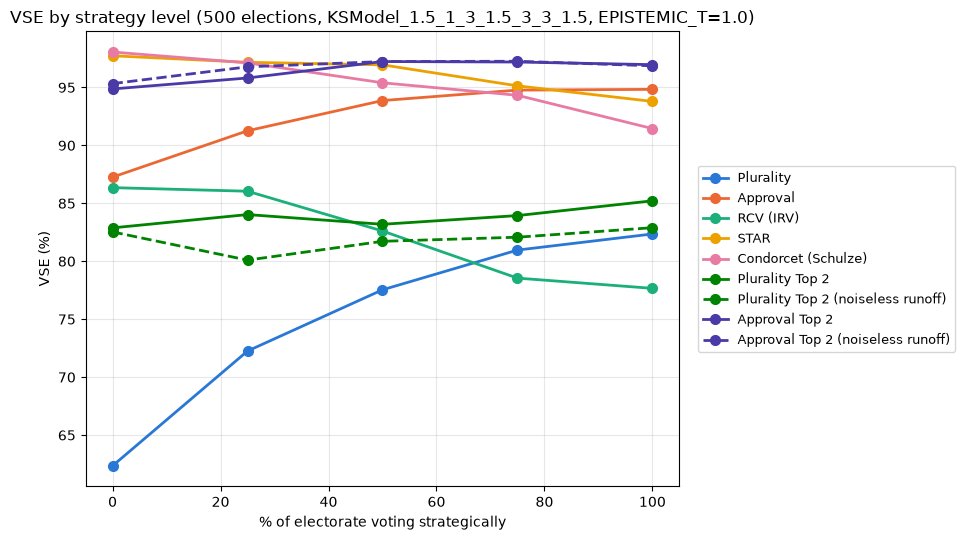

In [27]:
STRATEGY_AXIS = {
    "100% honest": 0,
    "25% strategic": 25,
    "50% strategic": 50,
    "75% strategic": 75,
    "100% strategic": 100,
}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, _ in METHODS:
    points = sorted(
        (STRATEGY_AXIS[chooser_label], mean_)
        for chooser_label, mean_, _ in rows_by_method[label]
        if chooser_label in STRATEGY_AXIS
    )
    if not points:
        continue
    xs, ys = zip(*points)
    ax.plot(xs, [y * 100 for y in ys], marker="o", markersize=7, linewidth=2,
            color=METHOD_COLORS[label], linestyle=METHOD_LINESTYLES[label], label=label)

ax.set_xlabel("% of electorate voting strategically")
ax.set_ylabel("VSE (%)")
ax.set_title(f"VSE by strategy level ({NITER} elections, {MODEL}, EPISTEMIC_T={EPISTEMIC_T})")
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Epistemic noise: VSE vs. voter information (honest & strategic)

Sweep `EPISTEMIC_T` and re-run VSE for each method, for both the **honest** ballot and the **100%
strategic** ballot, to see how much simply *being uncertain about your own preferences*
(independent of strategic behavior) erodes outcome quality — and whether that erosion looks
different for methods where honest and strategic don't behave the same way (see the Approval note
in Section 8: Approval's strategic ballot actually *outperforms* its honest one, the opposite of
Score(10)). Uses a smaller `SWEEP_NITER` than the main run above to keep this quick — expect
noisier per-point estimates. Two panels, sharing a y-axis, so the shapes are directly comparable;
each method keeps the same color as every other chart in this notebook (`METHOD_COLORS` above).


t=0.30 done
t=0.50 done
t=0.70 done
t=0.85 done
t=1.00 done


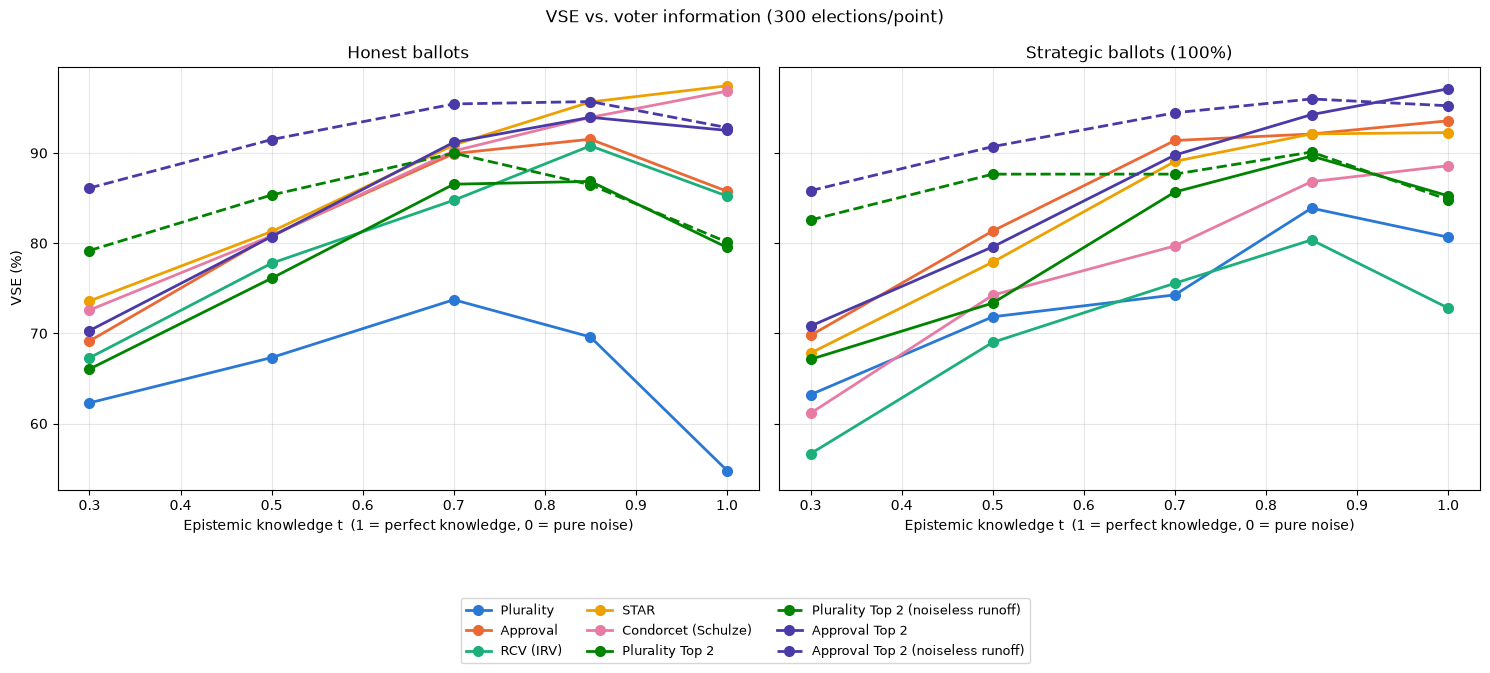

In [29]:
SWEEP_NITER = 300
T_VALUES = [0.3, 0.5, 0.7, 0.85, 1.0]

sweep_results_by_t = {}  # t -> {(label, chooser): (mean, ci)} -- the full breakdown, kept
                          # around so Section 11's range table can reuse it without re-running.
noise_sweep_honest = {label: [] for label, _ in METHODS}
noise_sweep_strategic = {label: [] for label, _ in METHODS}
for t in T_VALUES:
    sweep_summary = run_vse_simulation(MODEL, METHODS, NVOT, NCAND, SWEEP_NITER, CHOOSER_FUNS, MEDIA, epistemic_t=t)
    sweep_results = reduce_to_mean_ci(sweep_summary)
    sweep_results_by_t[t] = sweep_results
    for label, _ in METHODS:
        honest_mean, honest_ci = sweep_results[(label, "honBallot")]
        strat_mean, strat_ci = sweep_results[(label, "stratBallot")]
        noise_sweep_honest[label].append((t, honest_mean, honest_ci))
        noise_sweep_strategic[label].append((t, strat_mean, strat_ci))
    print(f"t={t:.2f} done")

fig, (ax_hon, ax_strat) = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for label, _ in METHODS:
    color = METHOD_COLORS[label]
    style = METHOD_LINESTYLES[label]

    hon_ts = [t for t, _, _ in noise_sweep_honest[label]]
    hon_vses = [v * 100 for _, v, _ in noise_sweep_honest[label]]
    ax_hon.plot(hon_ts, hon_vses, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)

    strat_ts = [t for t, _, _ in noise_sweep_strategic[label]]
    strat_vses = [v * 100 for _, v, _ in noise_sweep_strategic[label]]
    ax_strat.plot(strat_ts, strat_vses, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)

ax_hon.set_title("Honest ballots")
ax_strat.set_title("Strategic ballots (100%)")
for ax in (ax_hon, ax_strat):
    ax.set_xlabel("Epistemic knowledge t  (1 = perfect knowledge, 0 = pure noise)")
    ax.grid(True, alpha=0.3)
ax_hon.set_ylabel("VSE (%)")

handles, labels_ = ax_hon.get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.22))
fig.suptitle(f"VSE vs. voter information ({SWEEP_NITER} elections/point)")
plt.tight_layout()
plt.show()


## 12. VSE range by epistemic knowledge (t)

For each method, how much does VSE vary across *strategy levels* (honest through fully
strategic, including the one-sided/mixed variants), at a given level of voter information `t`?
Reuses the sweep from Section 10 above — no new simulation.

This orientation (fix `t`, range over strategy) rather than the opposite (fix strategy, range
over `t`) directly extends the "VSE range" convention already used in Section 8 and in the
original project's docs (e.g. "STAR: 91-98%") — those documented ranges are exactly this
table's `t=1.00` column. Reading down a column answers "how much does strategic behavior
matter, at this level of voter information?"; reading across a row answers "does that
strategy-sensitivity shrink or grow as voters get less informed?" (The other framing is the
same data transposed — Section 10's two-panel chart already tells that story directly for
honest vs. 100% strategic.)


In [30]:
from IPython.display import Markdown, display

header_cells = ["Method"] + [f"t={t:.2f}" for t in T_VALUES]
lines = [
    "| " + " | ".join(header_cells) + " |",
    "|" + "---|" * len(header_cells),
]
for label, _ in METHODS:
    row_cells = [label]
    for t in T_VALUES:
        vses = [mean_ for (lbl, chooser), (mean_, ci) in sweep_results_by_t[t].items() if lbl == label]
        lo, hi = min(vses) * 100, max(vses) * 100
        row_cells.append(f"{lo:.1f}-{hi:.1f}%")
    lines.append("| " + " | ".join(row_cells) + " |")

display(Markdown("\n".join(lines)))


| Method | t=0.30 | t=0.50 | t=0.70 | t=0.85 | t=1.00 |
|---|---|---|---|---|---|
| Plurality | 28.3-64.6% | 38.5-71.8% | 52.3-74.6% | 64.0-83.9% | 54.8-80.7% |
| Approval | 51.3-70.4% | 69.1-81.4% | 79.0-91.4% | 82.0-92.4% | 80.7-93.8% |
| RCV (IRV) | 54.2-67.3% | 69.0-77.8% | 75.1-84.8% | 80.4-90.8% | 72.8-85.2% |
| STAR | 49.0-73.6% | 67.3-82.6% | 82.4-90.9% | 85.0-95.7% | 89.4-97.5% |
| Condorcet (Schulze) | 52.8-72.6% | 63.5-80.8% | 72.3-90.2% | 77.1-94.0% | 83.8-96.9% |
| Plurality Top 2 | 63.7-67.8% | 72.6-76.1% | 83.1-86.7% | 84.6-89.7% | 79.5-85.5% |
| Plurality Top 2 (noiseless runoff) | 75.5-82.7% | 83.5-87.7% | 84.9-90.0% | 86.5-90.1% | 79.6-84.8% |
| Approval Top 2 | 62.0-72.6% | 73.6-80.7% | 87.1-91.2% | 90.9-94.3% | 91.7-97.1% |
| Approval Top 2 (noiseless runoff) | 79.0-86.7% | 84.4-91.5% | 91.0-95.4% | 90.0-97.0% | 89.5-96.5% |

## 13. Next steps

**Done:** the notebook is fully standalone (Section 1's vendored library has no dependency on
the `vse-sim` repository), epistemic noise is implemented (Section 2), and two Top-2 hybrid
methods with both runoff-noise variants are implemented and running above (Section 3): Plurality
Top 2 and Approval Top 2, each with a noisy-runoff and a noiseless-runoff instance.

**Still pending, for a future checkpoint:**

- **Participation friction / ballot fatigue** (forced truncation to a voter's top-K candidates):
  ballots are generated per-voter by chooser functions called inside `Method.resultsFor`.
  `RankedMethod.fillPrefOrder` already accepts `nSlots`/`remainderScore` parameters — precisely
  what's needed to truncate a ranked ballot (Plurality and `PluralityTop2` already use this same
  mechanism). Rated methods (Score/Srv/`ApprovalTop2`) would need an analogous post-hoc step: mask
  every candidate outside a voter's top-K back down to a floor score.
- **Top-3 hybrid methods** (e.g. "Approval Top 3 → Schulze"): `Top2Base` above generalizes in
  spirit — slice the primary's top N instead of top 2, then hand those N off to a *method*
  (Schulze) instead of a bare pairwise comparison, running that second method's own honest/
  strategic ballot logic restricted to the N finalists. Not built yet; `Top2Base.results()` would
  need to become "tally primary → pick top N → run a full second `Method` on those N `Voter`s'
  utilities" rather than the current single `sign()` comparison.
- **Heterogeneous/per-voter epistemic noise**, and specifically **reduced noise in the runoff
  stage of a Top-3 hybrid** (this checkpoint only supports "noisy" vs. "fully noiseless" for the
  binary Top-2 runoff — a Top-3-to-Schulze hybrid might instead want a *partially* reduced `t` for
  the runoff, not just on/off).

Neither of these is implemented in this notebook yet.
